# HITL - Human In The Loop 人机环路

## 三种常见操作
* 审批
* 编辑图状态
* 输入提供

## 中断机制
* 静态中断：在编译时确定的中断点
    * interrupt_before="node_name"：在指定节点执行前中断
    * interrupt_after="node_name"：在指定节点执行后中断

* 动态中断：通过 interrupt() 函数在节点内部触发的中断



In [2]:
from typing import Literal
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict
from langgraph.graph import MessagesState, StateGraph, END, START
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

# 定义状态类型
class ApprovalState(TypedDict):
    topic: str
    proposed_action_details: str
    final_result: str

# 定义节点函数
def propose_action(state: ApprovalState) -> ApprovalState:
    """提出一个需要人类审批的操作"""
    return {
        **state,
        "proposed_action_details": f"基于主题 '{state['topic']}' 的操作提议：发送营销邮件给1000个客户"
    }

def human_approval_node(state: ApprovalState) -> Command[Literal["execute_action", "revise_action"]]:
    """获取人类审批的节点"""
    approval_request = interrupt(
        {
            "question": "是否批准执行以下操作？",
            "action_details": state["proposed_action_details"],
            "options": ["approve", "deny"]
        }
    )

    if approval_request.get("user_response") == "approve":
        return Command(goto="execute_action")
    else:
        return Command(goto="revise_action")

def execute_action(state: ApprovalState) -> ApprovalState:
    """执行已批准的操作"""
    return {
        **state,
        "final_result": f"✅ 已执行操作: {state['proposed_action_details']}"
    }

def revise_action(state: ApprovalState) -> ApprovalState:
    """修改被拒绝的操作"""
    return {
        **state, 
        "final_result": f"❌ 操作被拒绝，已修改为: 发送营销邮件给50个目标客户（缩小规模）"
    }

# 构建需要人工审批的图
approval_graph_builder = StateGraph(ApprovalState)

# 添加节点
approval_graph_builder.add_node("propose_action", propose_action)
approval_graph_builder.add_node("human_approval", human_approval_node)
approval_graph_builder.add_node("execute_action", execute_action)
approval_graph_builder.add_node("revise_action", revise_action)

# 添加边
approval_graph_builder.add_edge(START, "propose_action")
approval_graph_builder.add_edge("propose_action", "human_approval")
approval_graph_builder.add_edge("revise_action", "human_approval")  # 修改后再次请求审批

# 编译图（必须包含检查点器以支持中断）
approval_graph = approval_graph_builder.compile(checkpointer=MemorySaver())

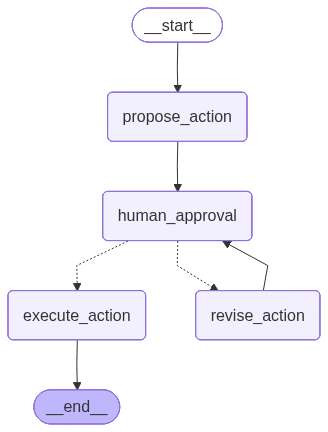

In [5]:
from IPython.display import Image, display
try:
    display(Image(approval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [7]:
# 启动审批流程
config = {"configurable": {"thread_id": "approval_thread"}}

print("=== 第一步：启动智能体，等待人工审批 ===")
try:
    result = approval_graph.invoke(
        {"topic": "产品推广活动"}, 
        config=config
    )
    print("执行完成：", result)
except Exception as e:
    print(f"智能体在等待人工审批处中断: {e}")
    
# 检查当前状态
current_state = approval_graph.get_state(config)
print(f"\n当前状态: {current_state.values}")
print(f"下一个节点: {current_state.next}")
print(f"是否被中断: {current_state.tasks[0] if current_state.tasks else 'No interrupts'}")

# 模拟人工拒绝审批
print("\n=== 第二步：人工拒绝审批 ===")
try:
    result = approval_graph.invoke(
        Command(resume={"user_response": "deny"}), 
        config=config
    )
    print("拒绝后的执行结果：", result)
except Exception as e:
    print(f"继续等待审批: {e}")
    
# 再次检查状态
current_state = approval_graph.get_state(config)
print(f"\n更新后状态: {current_state.values}")
print(f"下一个节点: {current_state.next}")

# 最终批准修改后的操作
print("\n=== 第三步：批准修改后的操作 ===")
final_result = approval_graph.invoke(
    Command(resume={"user_response": "approve"}), 
    config=config
)
print("最终执行结果：", final_result["final_result"])

=== 第一步：启动智能体，等待人工审批 ===
执行完成： {'topic': '产品推广活动', 'proposed_action_details': "基于主题 '产品推广活动' 的操作提议：发送营销邮件给1000个客户", 'final_result': '❌ 操作被拒绝，已修改为: 发送营销邮件给50个目标客户（缩小规模）', '__interrupt__': [Interrupt(value={'question': '是否批准执行以下操作？', 'action_details': "基于主题 '产品推广活动' 的操作提议：发送营销邮件给1000个客户", 'options': ['approve', 'deny']}, id='e8c933c154a5990853042bc4665f08ac')]}

当前状态: {'topic': '产品推广活动', 'proposed_action_details': "基于主题 '产品推广活动' 的操作提议：发送营销邮件给1000个客户", 'final_result': '❌ 操作被拒绝，已修改为: 发送营销邮件给50个目标客户（缩小规模）'}
下一个节点: ('human_approval',)
是否被中断: PregelTask(id='93f73d1c-e269-2c24-5bbd-738c8c16db71', name='human_approval', path=('__pregel_pull', 'human_approval'), error=None, interrupts=(Interrupt(value={'question': '是否批准执行以下操作？', 'action_details': "基于主题 '产品推广活动' 的操作提议：发送营销邮件给1000个客户", 'options': ['approve', 'deny']}, id='e8c933c154a5990853042bc4665f08ac'),), state=None, result=None)

=== 第二步：人工拒绝审批 ===
拒绝后的执行结果： {'topic': '产品推广活动', 'proposed_action_details': "基于主题 '产品推广活动' 的操作提议：发送营销邮件给1000个客户", 